# Sinusoid Laplace: 5-Seed Evaluation

Fits the Laplace variants below (subset of weights x Hessian structure x tuning method) on the sinusoid regression task over 5 random seeds. Checkpoints use `sinusoid_laplace_5seed/` and figures use the `5seed_sinusoid_` prefix.

In [1]:
from pathlib import Path
import sys, os, time, copy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm as _norm

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "shared").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from shared import (checkpoint_exists, load_checkpoint, save_checkpoint,
                    seed_everything, regression_metrics, load_sinusoid,
                    combine_predictive_std, get_sinusoid_mlp, la_predict,
                    build_laplace_variant, tune_laplace_adam_loop,
                    aggregate_seed_metrics, regression_calibration_curve,
                    plot_regression_prediction_bands, plot_regression_ood_epistemic,
                    plot_regression_calibration)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SEEDS = [711, 42, 123, 456, 789]
sigma_noise = 0.3
TRAIN_LO, TRAIN_HI = 0.0, 8.0

FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_laplace_5seed")
os.makedirs(CHECKPOINT_BASE, exist_ok=True)
MAP_CHECKPOINT_BASE = str(ROOT / "results" / "checkpoints" / "sinusoid_map_5seed")
os.makedirs(MAP_CHECKPOINT_BASE, exist_ok=True)

plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "savefig.dpi": 150, "savefig.bbox": "tight"})
print(f"5-seed Laplace regression | {len(SEEDS)} seeds | checkpoints -> {CHECKPOINT_BASE}")

Device: cuda
5-seed Laplace regression | 5 seeds | checkpoints -> /u/halle/carg/home_at/Documents/BNNs/results/checkpoints/sinusoid_laplace_5seed


In [2]:
# Deterministic evaluation grid (torch.linspace, independent of seed)
x_grid = torch.linspace(-5, 13, 500).numpy()

# Variant specs: subset of weights x Hessian structure x tuning method
variant_specs = []
for subset, hessians in [("all", ["diag", "kron", "full"]), ("last_layer", ["full", "kron"])]:
    scope = "all" if subset == "all" else "last layer"
    for hessian in hessians:
        for tune in ["marglik", "gridsearch"]:
            variant_specs.append({
                "variant_name": f"{hessian}_{subset}_{tune}",
                "hessian": hessian, "subset": subset, "tune": tune,
                "plot_title": f"{hessian.capitalize()} / {scope} / {tune}",
            })
for subset in ["all", "last_layer"]:
    scope = "all" if subset == "all" else "last layer"
    variant_specs.append({
        "variant_name": f"kron_{subset}_adam_loop",
        "hessian": "kron", "subset": subset, "tune": "adam_loop",
        "plot_title": f"Kron / {scope} / adam loop",
    })
print(f"Configured {len(variant_specs)} variants x {len(SEEDS)} seeds = "
      f"{len(variant_specs)*len(SEEDS)} total fits")

Configured 12 variants x 5 seeds = 60 total fits


In [3]:
all_seed_metrics   = {}   # {seed: {vname: metrics_dict}}
all_seed_preds     = {}   # {seed: {vname: (f_mu_grid, epi_grid, sigma)}}
all_seed_la        = {}   # {seed: {vname: fitted Laplace object}}
all_seed_test_data = {}   # {seed: (X_test_id, y_test_id_np)}
all_seed_test_data_ood = {}   # {seed: (X_test_ood, y_test_ood_np)}

for seed in SEEDS:
    print(f"\n{'='*55}\nSEED {seed}  ({SEEDS.index(seed)+1}/{len(SEEDS)})\n{'='*55}")

    # ----- data -----
    d = load_sinusoid(n_data=150, sigma_noise=sigma_noise, batch_size=150, seed=seed, device=device)
    X_train, y_train = d["X_train"], d["y_train"]
    X_val, y_val     = d["X_val"], d["y_val"]
    X_test_id = d["X_test_id"]
    y_test_id = d["y_test_id"]
    y_test_id_np = y_test_id.cpu().flatten().numpy()
    all_seed_test_data[seed] = (X_test_id, y_test_id_np)
    X_test_ood = d["X_test_ood"]
    y_test_ood_np = d["y_test_ood"].cpu().flatten().numpy()
    all_seed_test_data_ood[seed] = (X_test_ood, y_test_ood_np)

    # ----- MAP -----
    criterion = torch.nn.MSELoss()
    X_test_grid = torch.linspace(-5, 13, 500).unsqueeze(-1).to(device)
    map_ckpt = os.path.join(MAP_CHECKPOINT_BASE, f"sinusoid_map_seed{seed}.pt")
    map_model = get_sinusoid_mlp(seed, device=device)
    if checkpoint_exists(map_ckpt):
        map_model.load_state_dict(
            load_checkpoint(map_ckpt, map_location=device)["model_state_dict"])
        print("  MAP: loaded checkpoint")
    else:
        opt = torch.optim.Adam(map_model.parameters(), lr=1e-2)
        t0 = time.time()
        for _ in range(1000):
            for xb, yb in d["train_loader"]:
                opt.zero_grad(); loss = criterion(map_model(xb), yb); loss.backward(); opt.step()
        save_checkpoint({"model_state_dict": map_model.state_dict(),
                         "fit_time": time.time()-t0}, map_ckpt)
        print(f"  MAP: trained ({time.time()-t0:.1f}s)")
    map_model.eval()
    with torch.no_grad():
        map_resid_std = float((y_train - map_model(X_train)).std().item())

    seed_metrics, seed_preds = {}, {}
    for spec in variant_specs:
        vname = spec["variant_name"]
        la_ckpt = os.path.join(CHECKPOINT_BASE, f"sinusoid_laplace_{vname}_seed{seed}.pt")

        la = build_laplace_variant(
            get_sinusoid_mlp(seed, device=device), map_model, spec, "regression",
            subset_key="subset", hessian_key="hessian")

        loaded = False
        if checkpoint_exists(la_ckpt):
            payload = load_checkpoint(la_ckpt, map_location=device)
            if isinstance(payload, dict) and payload.get("la_state_dict") is not None:
                la.load_state_dict(payload["la_state_dict"])
                metrics = payload.get("metrics", {})
                loaded = True

        if not loaded:
            t0 = time.time(); la.fit(d["train_loader"])
            metrics = {
                "Hessian_Structure": spec["hessian"],
                "Subset_Of_Weights": spec["subset"],
                "Tune_Method": spec["tune"],
                "Fit_Time (s)": time.time()-t0,
            }
            t1 = time.time()
            if spec["tune"] == "adam_loop":
                tune_laplace_adam_loop(la)
            else:
                la.sigma_noise = torch.tensor(map_resid_std)
                if spec["tune"] == "marglik":
                    la.optimize_prior_precision(method="marglik")
                else:
                    la.optimize_prior_precision(method="gridsearch", val_loader=d["val_loader"])
            metrics["Tune_Time (s)"] = time.time()-t1
            metrics["Prior_Precision"] = float(
                np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])
            metrics["Sigma_Noise"] = float(la.sigma_noise.item())
            save_checkpoint({"la_state_dict": la.state_dict(),
                             "metrics": metrics}, la_ckpt)

        sigma = float(la.sigma_noise.item())
        metrics["Sigma_Noise"] = sigma
        metrics["Prior_Precision"] = float(
            np.atleast_1d(la.prior_precision.detach().cpu().numpy())[0])

        f_mu_grid, epi_grid = la_predict(la, X_test_grid)
        t_inf = time.time()
        mu_id, epi_id = la_predict(la, X_test_id)
        metrics["Inf_Time (s)"] = time.time() - t_inf
        total_id = combine_predictive_std(epi_id, sigma)
        metrics.update(regression_metrics(y_test_id_np, mu_id, total_id))

        seed_metrics[vname] = metrics
        seed_preds[vname] = (f_mu_grid, epi_grid, sigma)
        all_seed_la.setdefault(seed, {})[vname] = la
        print(f"  {vname}: RMSE={metrics.get('RMSE',float('nan')):.4f}  "
              f"NLL={metrics.get('NLL',float('nan')):.4f}  "
              f"Cal={metrics.get('Calibration_Error',float('nan')):.4f}")

    all_seed_metrics[seed] = seed_metrics
    all_seed_preds[seed] = seed_preds

print(f"\nCompleted {len(SEEDS)} seeds x {len(variant_specs)} variants.")


SEED 711  (1/5)
  MAP: loaded checkpoint


  diag_all_marglik: RMSE=0.3006  NLL=0.3159  Cal=1.1147
  diag_all_gridsearch: RMSE=0.3006  NLL=0.2872  Cal=0.8369
  kron_all_marglik: RMSE=0.3006  NLL=0.2341  Cal=0.4242
  kron_all_gridsearch: RMSE=0.3006  NLL=0.2279  Cal=0.3383
  full_all_marglik: RMSE=0.3006  NLL=0.2285  Cal=0.3269
  full_all_gridsearch: RMSE=0.3006  NLL=0.2236  Cal=0.2826


  full_last_layer_marglik: RMSE=0.3006  NLL=0.2251  Cal=0.2965
  full_last_layer_gridsearch: RMSE=0.3006  NLL=0.2232  Cal=0.2810
  kron_last_layer_marglik: RMSE=0.3006  NLL=0.2256  Cal=0.2963
  kron_last_layer_gridsearch: RMSE=0.3006  NLL=0.2242  Cal=0.2858
  kron_all_adam_loop: RMSE=0.3006  NLL=0.2333  Cal=0.4185
  kron_last_layer_adam_loop: RMSE=0.3006  NLL=0.2250  Cal=0.2965

SEED 42  (2/5)
  MAP: loaded checkpoint
  diag_all_marglik: RMSE=0.3254  NLL=0.3214  Cal=0.4580
  diag_all_gridsearch: RMSE=0.3254  NLL=0.3277  Cal=0.4816
  kron_all_marglik: RMSE=0.3254  NLL=0.3031  Cal=0.3725


  kron_all_gridsearch: RMSE=0.3254  NLL=0.3030  Cal=0.3725
  full_all_marglik: RMSE=0.3254  NLL=0.3048  Cal=0.4181
  full_all_gridsearch: RMSE=0.3254  NLL=0.3089  Cal=0.4647
  full_last_layer_marglik: RMSE=0.3254  NLL=0.3084  Cal=0.4498
  full_last_layer_gridsearch: RMSE=0.3254  NLL=0.3092  Cal=0.4627
  kron_last_layer_marglik: RMSE=0.3254  NLL=0.3077  Cal=0.4359
  kron_last_layer_gridsearch: RMSE=0.3254  NLL=0.3070  Cal=0.4333
  kron_all_adam_loop: RMSE=0.3254  NLL=0.3035  Cal=0.3811
  kron_last_layer_adam_loop: RMSE=0.3254  NLL=0.3085  Cal=0.4498

SEED 123  (3/5)
  MAP: loaded checkpoint
  diag_all_marglik: RMSE=0.3238  NLL=0.3083  Cal=0.3464
  diag_all_gridsearch: RMSE=0.3238  NLL=0.3194  Cal=0.4436


  kron_all_marglik: RMSE=0.3238  NLL=0.2951  Cal=0.3501
  kron_all_gridsearch: RMSE=0.3238  NLL=0.2847  Cal=0.2724
  full_all_marglik: RMSE=0.3238  NLL=0.3055  Cal=0.4060
  full_all_gridsearch: RMSE=0.3238  NLL=0.3061  Cal=0.4060
  full_last_layer_marglik: RMSE=0.3238  NLL=0.3127  Cal=0.4384
  full_last_layer_gridsearch: RMSE=0.3238  NLL=0.3064  Cal=0.4237
  kron_last_layer_marglik: RMSE=0.3238  NLL=0.3119  Cal=0.4384
  kron_last_layer_gridsearch: RMSE=0.3238  NLL=0.2924  Cal=0.3620
  kron_all_adam_loop: RMSE=0.3238  NLL=0.2959  Cal=0.3571


  kron_last_layer_adam_loop: RMSE=0.3238  NLL=0.3131  Cal=0.4433

SEED 456  (4/5)
  MAP: loaded checkpoint
  diag_all_marglik: RMSE=0.3196  NLL=0.3377  Cal=0.4988
  diag_all_gridsearch: RMSE=0.3196  NLL=0.2768  Cal=0.0423
  kron_all_marglik: RMSE=0.3196  NLL=0.2827  Cal=0.0575
  kron_all_gridsearch: RMSE=0.3196  NLL=0.2780  Cal=0.0414
  full_all_marglik: RMSE=0.3196  NLL=0.2803  Cal=0.0413
  full_all_gridsearch: RMSE=0.3196  NLL=0.2785  Cal=0.0418
  full_last_layer_marglik: RMSE=0.3196  NLL=0.2795  Cal=0.0439
  full_last_layer_gridsearch: RMSE=0.3196  NLL=0.2788  Cal=0.0418
  kron_last_layer_marglik: RMSE=0.3196  NLL=0.2794  Cal=0.0413
  kron_last_layer_gridsearch: RMSE=0.3196  NLL=0.2788  Cal=0.0418
  kron_all_adam_loop: RMSE=0.3196  NLL=0.2824  Cal=0.0564
  kron_last_layer_adam_loop: RMSE=0.3196  NLL=0.2795  Cal=0.0439

SEED 789  (5/5)
  MAP: loaded checkpoint
  diag_all_marglik: RMSE=0.3171  NLL=0.3342  Cal=0.7172
  diag_all_gridsearch: RMSE=0.3171  NLL=0.3470  Cal=0.9152
  kron_all

In [4]:
# Aggregate metrics across seeds (mean ± std per variant)
metric_keys = [
    "RMSE", "NLL", "Calibration_Error",
    "Fit_Time (s)", "Tune_Time (s)", "Inf_Time (s)",
]

agg = {}
for spec in variant_specs:
    vname = spec["variant_name"]
    agg[vname] = aggregate_seed_metrics(
        [all_seed_metrics[s][vname] for s in SEEDS], metric_keys)

# Display as mean ± std table
rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {mk: f"{agg[vname][f'{mk}_mean']:.4f} ± {agg[vname][f'{mk}_std']:.4f}"
           for mk in metric_keys}
    rows.append(row)
summary_df = pd.DataFrame(rows, index=[s["plot_title"] for s in variant_specs])
summary_df.index.name = "Variant"
print(f"Sinusoid Laplace: {len(SEEDS)}-seed metrics (mean ± std)")
display(summary_df)

# Save raw means/stds for downstream use
agg_flat = []
for spec in variant_specs:
    vname = spec["variant_name"]
    row = {"Variant": spec["plot_title"]}
    row.update(agg[vname])
    agg_flat.append(row)
agg_df = pd.DataFrame(agg_flat).set_index("Variant")
os.makedirs("results/metrics", exist_ok=True)
agg_df.to_csv("results/metrics/sinusoid_laplace_5seed_metrics.csv")
print("\nSaved to results/metrics/sinusoid_laplace_5seed_metrics.csv")


Sinusoid Laplace — 5-seed metrics (mean ± std)


,RMSE,NLL,Calibration_Error,Fit_Time (s),Tune_Time (s),Inf_Time (s)
Variant,,,,,,
Diag / all / marglik,0.3173 ± 0.0089,0.3235 ± 0.0110,0.6270 ± 0.2719,0.1734 ± 0.0469,0.0576 ± 0.0157,0.0039 ± 0.0013
Diag / all / gridsearch,0.3173 ± 0.0089,0.3116 ± 0.0260,0.5439 ± 0.3128,0.1766 ± 0.0093,10.8830 ± 1.3645,0.0035 ± 0.0016
Kron / all / marglik,0.3173 ± 0.0089,0.2763 ± 0.0244,0.2749 ± 0.1384,0.5081 ± 0.0652,0.0764 ± 0.0287,0.0014 ± 0.0001
Kron / all / gridsearch,0.3173 ± 0.0089,0.2738 ± 0.0249,0.2502 ± 0.1161,0.5084 ± 0.0586,14.5525 ± 2.2504,0.0040 ± 0.0051
Full / all / marglik,0.3173 ± 0.0089,0.2763 ± 0.0288,0.2725 ± 0.1455,5.3987 ± 2.4105,12.8536 ± 2.4717,0.0027 ± 0.0017
Full / all / gridsearch,0.3173 ± 0.0089,0.2758 ± 0.0314,0.2735 ± 0.1536,5.5491 ± 2.3150,19.4416 ± 2.6854,0.0033 ± 0.0017
Full / last layer / marglik,0.3173 ± 0.0089,0.2782 ± 0.0319,0.2832 ± 0.1539,0.1260 ± 0.0457,4.2892 ± 0.8991,0.0021 ± 0.0022
Full / last layer / gridsearch,0.3173 ± 0.0089,0.2762 ± 0.0316,0.2777 ± 0.1554,0.1186 ± 0.0320,9.0984 ± 1.8993,0.0016 ± 0.0018
Kron / last layer / marglik,0.3173 ± 0.0089,0.2780 ± 0.0314,0.2799 ± 0.1518,0.2322 ± 0.0385,0.0685 ± 0.0281,0.0024 ± 0.0033



Saved to results/metrics/sinusoid_laplace_5seed_metrics.csv


In [5]:
# ID vs OOD metrics: mean ± std across seeds, reusing the already-fitted
# Laplace objects and the OOD test split loaded above but not otherwise used.
def pm(vals):
    return f"{np.mean(vals):.4f} ± {np.std(vals):.4f}"

ood_rows = []
for spec in variant_specs:
    vname = spec["variant_name"]
    id_rmse, ood_rmse, id_nll, ood_nll = [], [], [], []
    epi_id_means, epi_ood_means, ratios = [], [], []
    for seed in SEEDS:
        X_test_id_s, y_test_id_s = all_seed_test_data[seed]
        X_test_ood_s, y_test_ood_s = all_seed_test_data_ood[seed]
        la = all_seed_la[seed][vname]
        sigma = float(la.sigma_noise.item())

        mu_id, epi_id = la_predict(la, X_test_id_s)
        mu_ood, epi_ood = la_predict(la, X_test_ood_s)
        m_id = regression_metrics(y_test_id_s, mu_id, combine_predictive_std(epi_id, sigma))
        m_ood = regression_metrics(y_test_ood_s, mu_ood, combine_predictive_std(epi_ood, sigma))

        id_rmse.append(m_id["RMSE"]); ood_rmse.append(m_ood["RMSE"])
        id_nll.append(m_id["NLL"]);   ood_nll.append(m_ood["NLL"])
        epi_id_means.append(epi_id.mean()); epi_ood_means.append(epi_ood.mean())
        ratios.append(epi_ood.mean() / (epi_id.mean() + 1e-12))

    ood_rows.append({
        "Variant": spec["plot_title"],
        "ID RMSE": pm(id_rmse), "OOD RMSE": pm(ood_rmse),
        "ID NLL": pm(id_nll), "OOD NLL": pm(ood_nll),
        "ID Epi": pm(epi_id_means), "OOD Epi": pm(epi_ood_means),
        "Epi Ratio": pm(ratios),
    })

ood_df = pd.DataFrame(ood_rows).set_index("Variant")
print(f"Sinusoid Laplace - ID vs OOD (mean ± std, {len(SEEDS)} seeds)")
display(ood_df)
ood_df.to_csv("results/metrics/sinusoid_laplace_5seed_ood_metrics.csv")
print("\nSaved to results/metrics/sinusoid_laplace_5seed_ood_metrics.csv")


Sinusoid Laplace - ID vs OOD (mean ± std, 5 seeds)


,ID RMSE,OOD RMSE,ID NLL,OOD NLL,ID Epi,OOD Epi,Epi Ratio
Variant,,,,,,,
Diag / all / marglik,0.3173 ± 0.0089,1.7251 ± 0.2111,0.3235 ± 0.0110,8.8069 ± 2.0845,0.2685 ± 0.0149,0.3694 ± 0.0781,1.3782 ± 0.2969
Diag / all / gridsearch,0.3173 ± 0.0089,1.7251 ± 0.2111,0.3116 ± 0.0260,9.9777 ± 2.8569,0.2337 ± 0.0766,0.4722 ± 0.2822,1.8358 ± 0.7986
Kron / all / marglik,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2763 ± 0.0244,2.6409 ± 0.8843,0.1200 ± 0.0083,1.9698 ± 0.3761,16.5712 ± 3.6787
Kron / all / gridsearch,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2738 ± 0.0249,7.0279 ± 5.0017,0.1169 ± 0.0443,7.9804 ± 9.0695,49.9767 ± 52.1547
Full / all / marglik,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2763 ± 0.0288,2.3095 ± 0.1344,0.0848 ± 0.0074,3.3301 ± 0.4270,39.5866 ± 6.3112
Full / all / gridsearch,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2758 ± 0.0314,8.7543 ± 5.4321,0.0639 ± 0.0233,1.8351 ± 2.2829,20.8547 ± 22.6022
Full / last layer / marglik,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2782 ± 0.0319,7.4864 ± 2.7718,0.0638 ± 0.0048,0.8398 ± 0.0922,13.2522 ± 1.8717
Full / last layer / gridsearch,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2762 ± 0.0316,10.3506 ± 6.0472,0.0564 ± 0.0182,1.8694 ± 2.1482,25.1688 ± 26.3214
Kron / last layer / marglik,0.3173 ± 0.0089,1.7251 ± 0.2111,0.2780 ± 0.0314,7.7077 ± 2.8282,0.0683 ± 0.0050,0.6955 ± 0.0930,10.2670 ± 1.7527



Saved to results/metrics/sinusoid_laplace_5seed_ood_metrics.csv


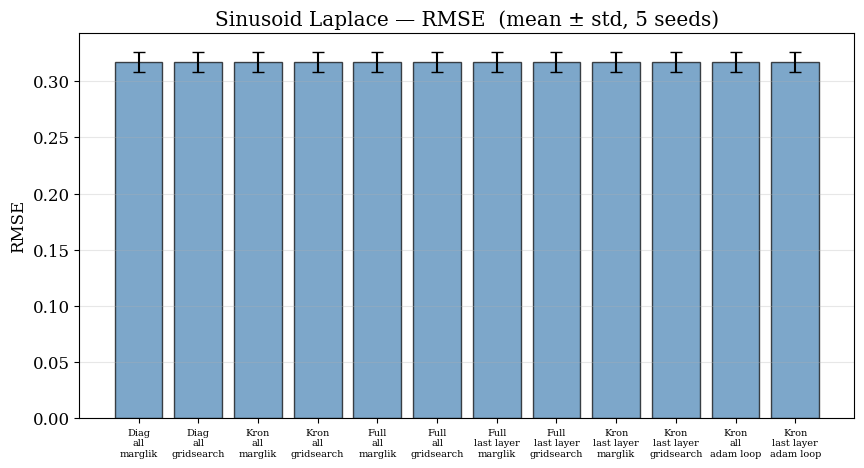

Saved: 5seed_sinusoid_laplace_rmse_bar.png


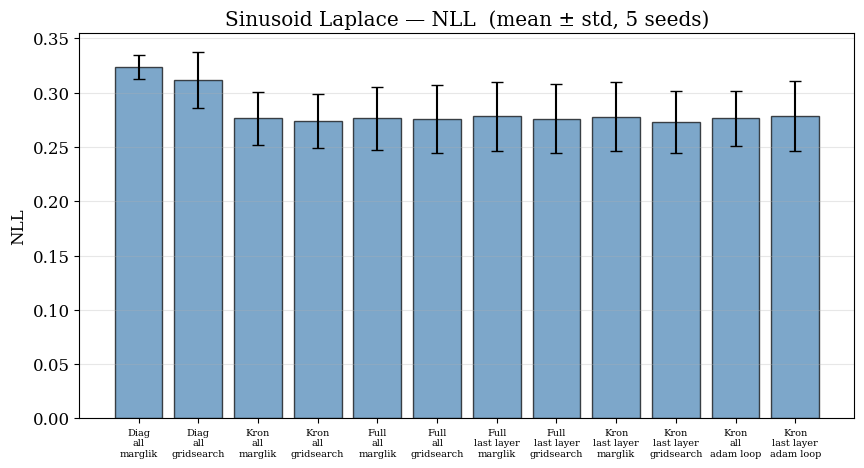

Saved: 5seed_sinusoid_laplace_nll_bar.png


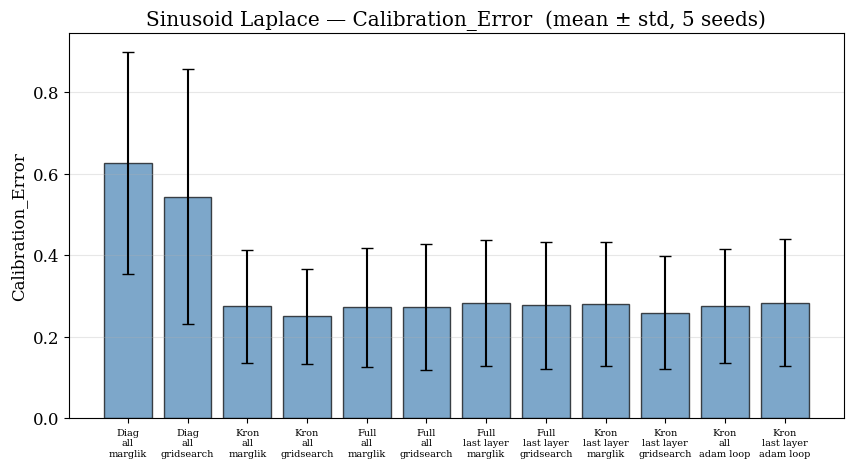

Saved: 5seed_sinusoid_laplace_calibration_error_bar.png


In [6]:
ABBREV = {"gridsearch": "gs", "all weights": "aw", "last layer": "ll", "marglik": "ml",
          "adam loop": "al"}
def abbreviate_title(t):
    for full, ab in ABBREV.items():
        t = t.replace(full, ab)
    return t.replace(" / ", "/")

plot_metrics = ["RMSE", "NLL", "Calibration_Error"]
titles = [abbreviate_title(s["plot_title"]) for s in variant_specs]
n = len(titles)
x = np.arange(n)

for mk in plot_metrics:
    means = [agg[s["variant_name"]][f"{mk}_mean"] for s in variant_specs]
    stds  = [agg[s["variant_name"]][f"{mk}_std"]  for s in variant_specs]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(x, means, yerr=stds, capsize=4, color="steelblue", alpha=0.7, edgecolor="k")
    ax.set_xticks(x)
    ax.set_xticklabels(titles, fontsize=12, rotation=30, ha="right")
    ax.set_ylabel(mk)
    ax.set_title(f"Sinusoid Laplace: {mk}  (mean \u00b1 std, {len(SEEDS)} seeds)")
    ax.grid(True, alpha=0.3, axis="y")
    fname = f"5seed_sinusoid_laplace_{mk.lower()}_bar.png"
    fig.savefig(os.path.join(FIGURES_DIR, fname), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")


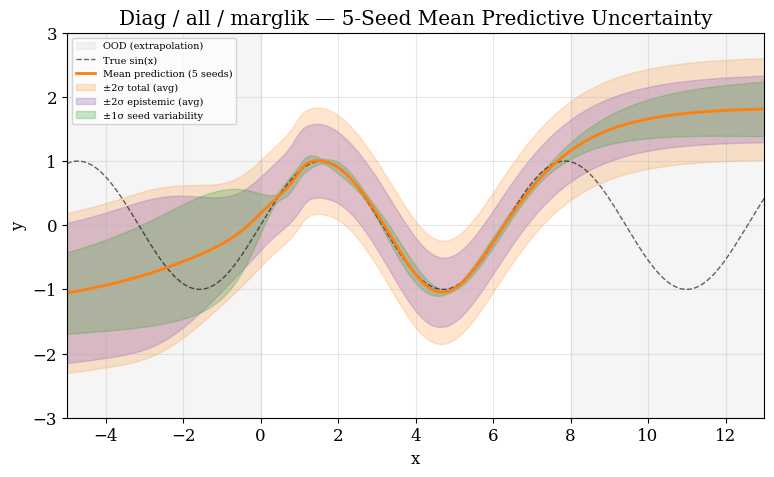

  Saved: 5seed_sinusoid_diag_all_marglik_prediction.png


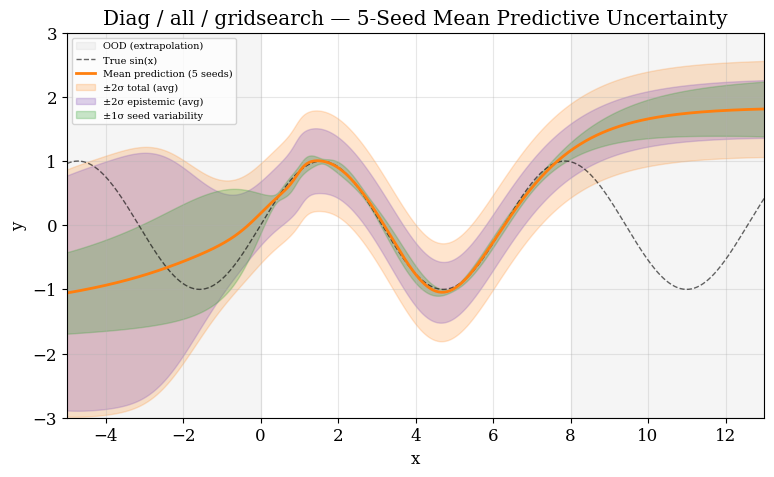

  Saved: 5seed_sinusoid_diag_all_gridsearch_prediction.png


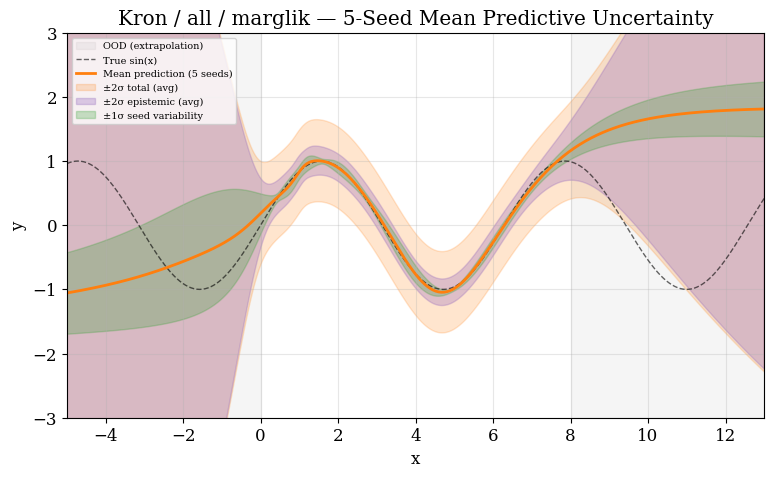

  Saved: 5seed_sinusoid_kron_all_marglik_prediction.png


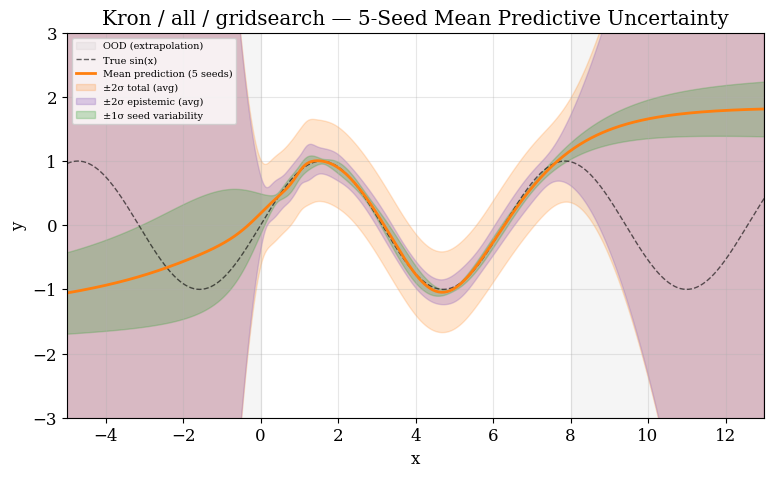

  Saved: 5seed_sinusoid_kron_all_gridsearch_prediction.png


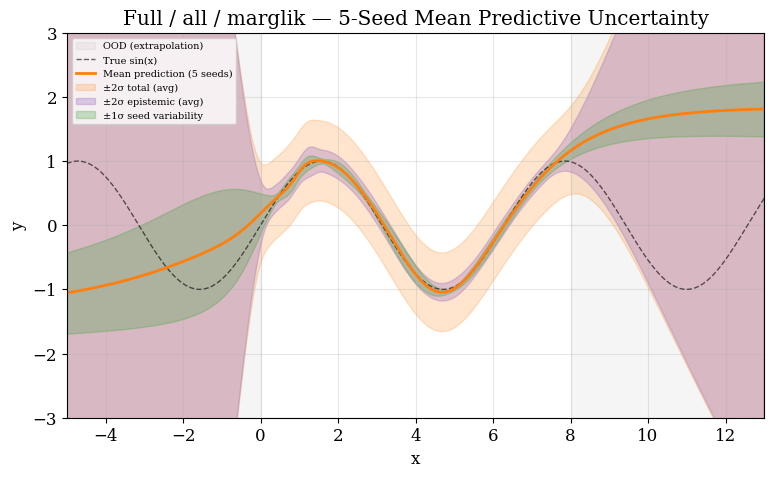

  Saved: 5seed_sinusoid_full_all_marglik_prediction.png


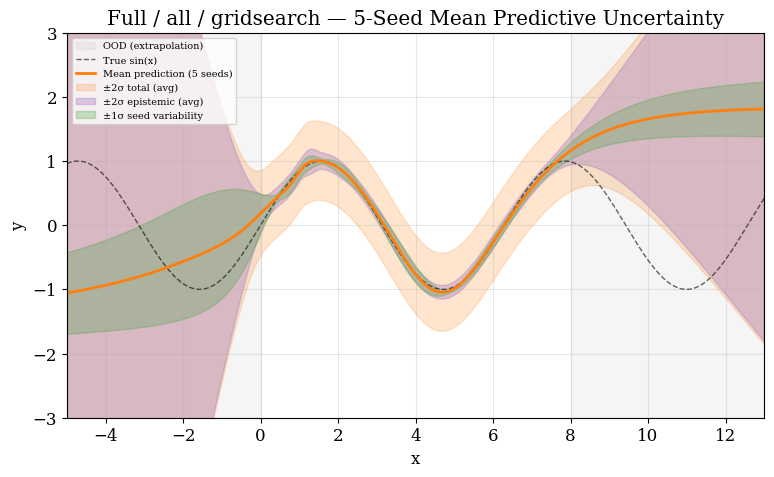

  Saved: 5seed_sinusoid_full_all_gridsearch_prediction.png


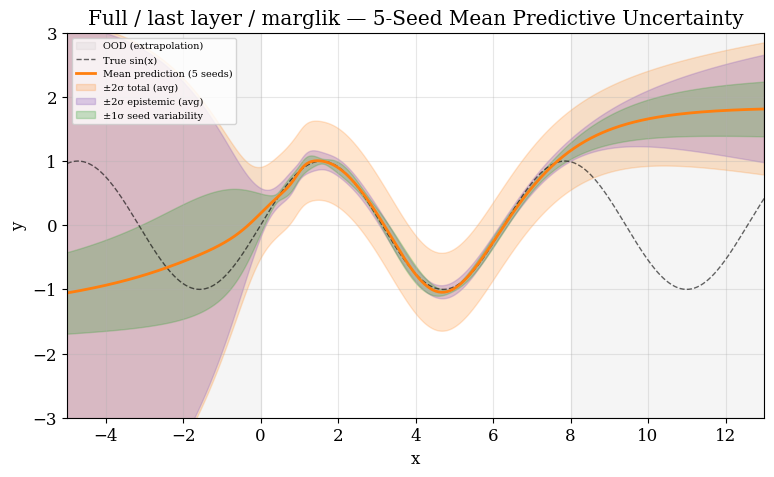

  Saved: 5seed_sinusoid_full_last_layer_marglik_prediction.png


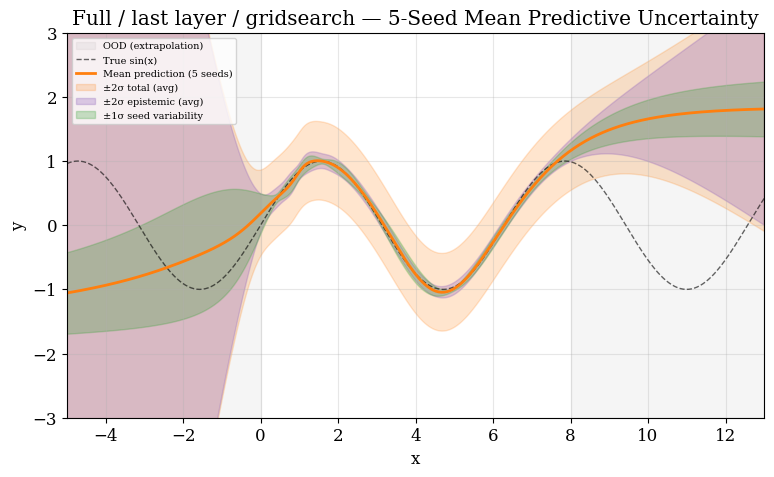

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_prediction.png


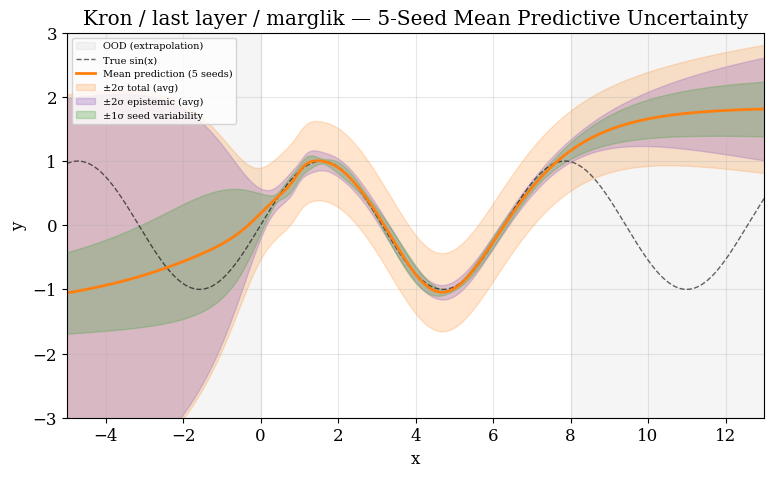

  Saved: 5seed_sinusoid_kron_last_layer_marglik_prediction.png


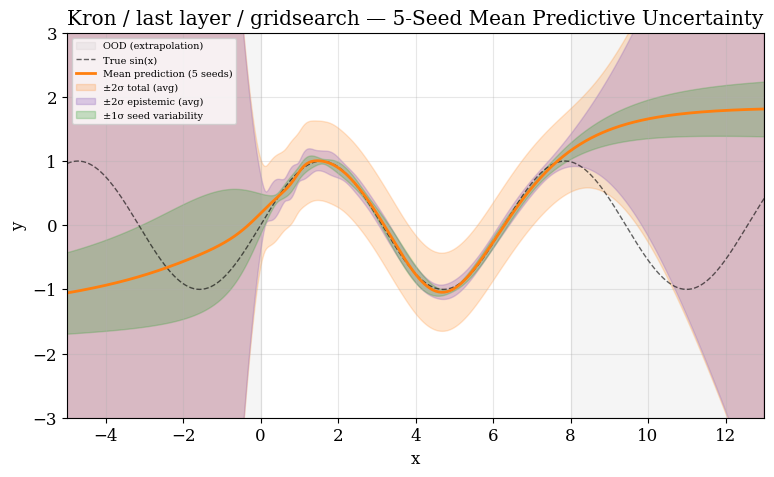

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_prediction.png


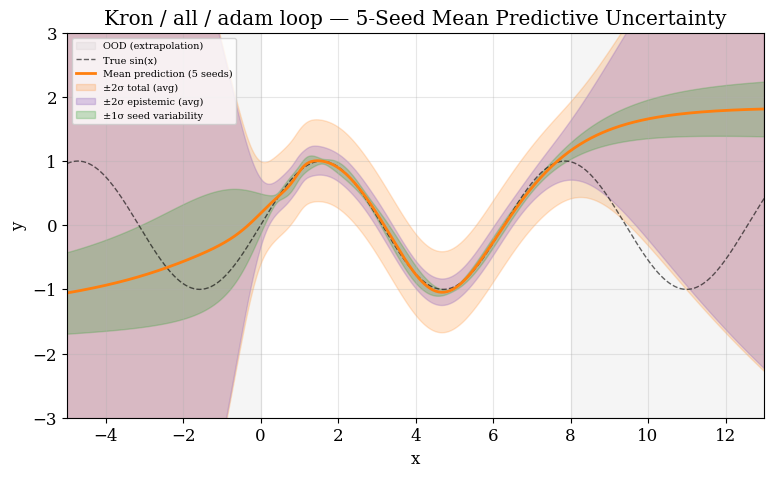

  Saved: 5seed_sinusoid_kron_all_adam_loop_prediction.png


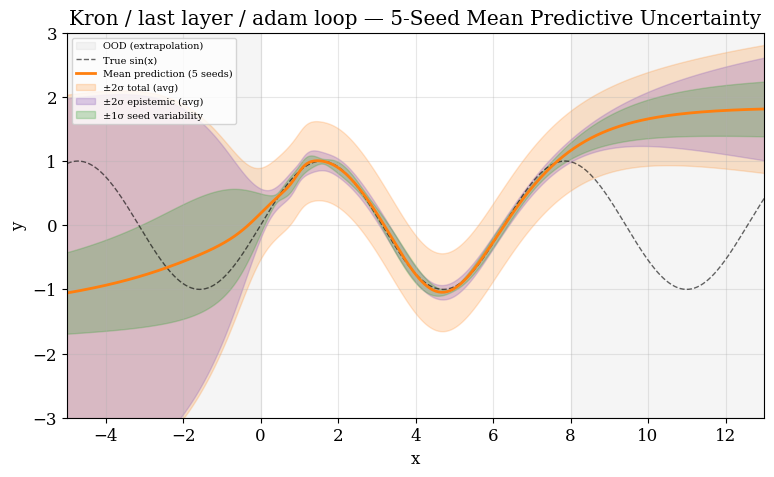

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_prediction.png

Done: 12 prediction figures


In [7]:
plot_regression_prediction_bands(
    variant_specs, all_seed_preds, SEEDS, x_grid, TRAIN_LO, TRAIN_HI,
    FIGURES_DIR, "5seed_sinusoid")

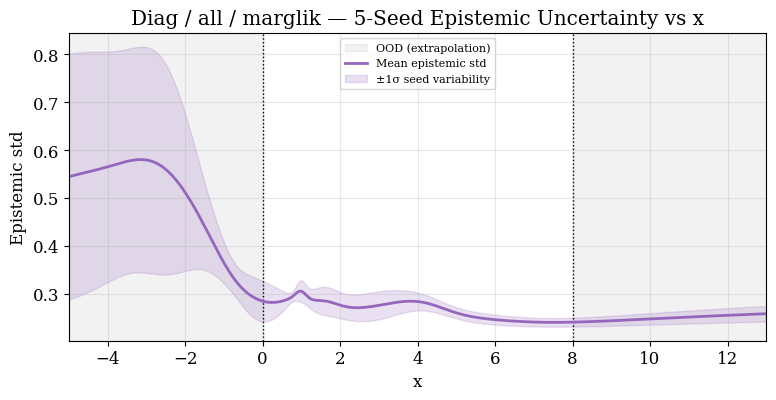

  Saved: 5seed_sinusoid_diag_all_marglik_ood_epistemic.png


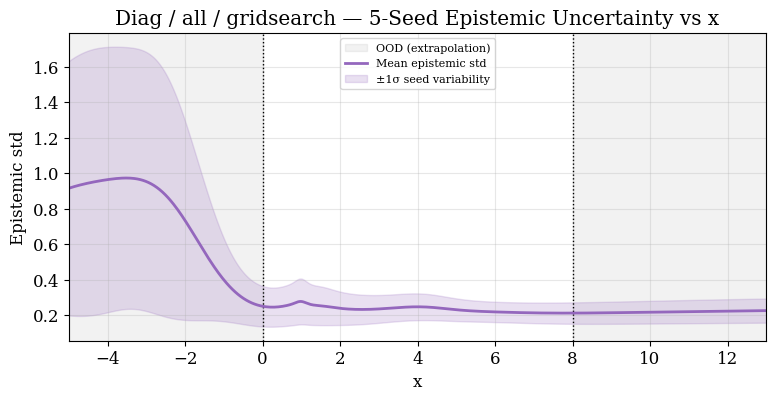

  Saved: 5seed_sinusoid_diag_all_gridsearch_ood_epistemic.png


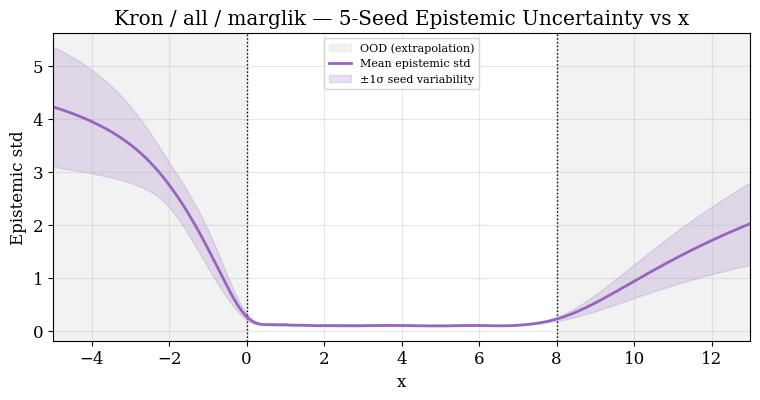

  Saved: 5seed_sinusoid_kron_all_marglik_ood_epistemic.png


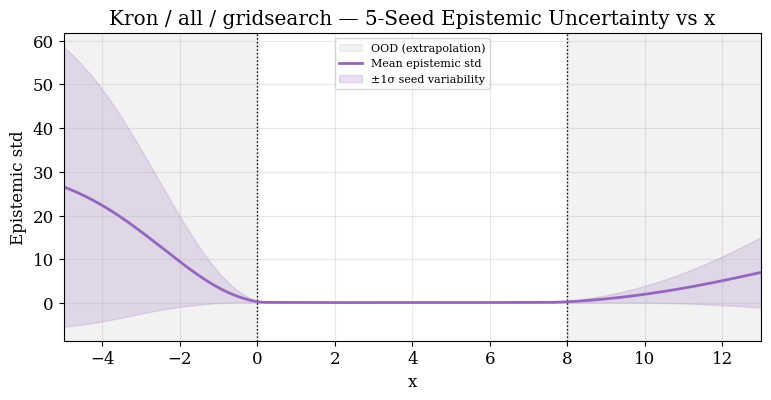

  Saved: 5seed_sinusoid_kron_all_gridsearch_ood_epistemic.png


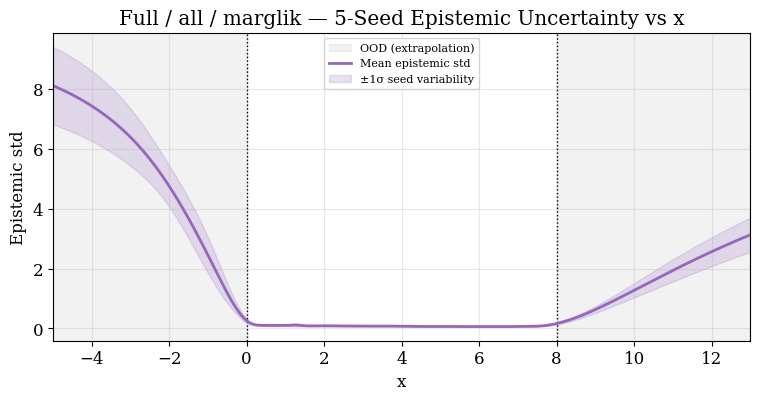

  Saved: 5seed_sinusoid_full_all_marglik_ood_epistemic.png


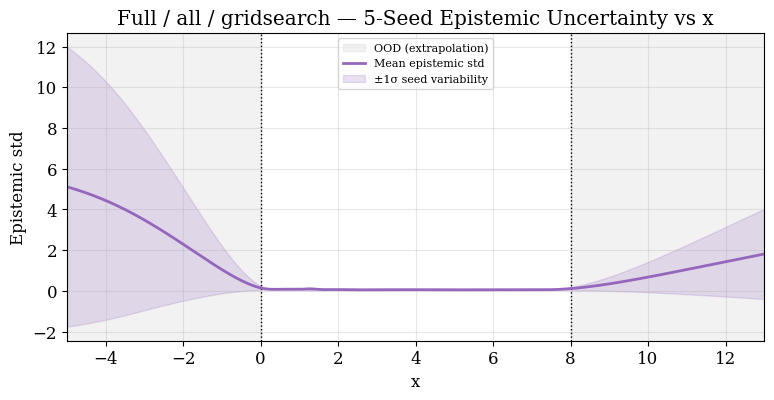

  Saved: 5seed_sinusoid_full_all_gridsearch_ood_epistemic.png


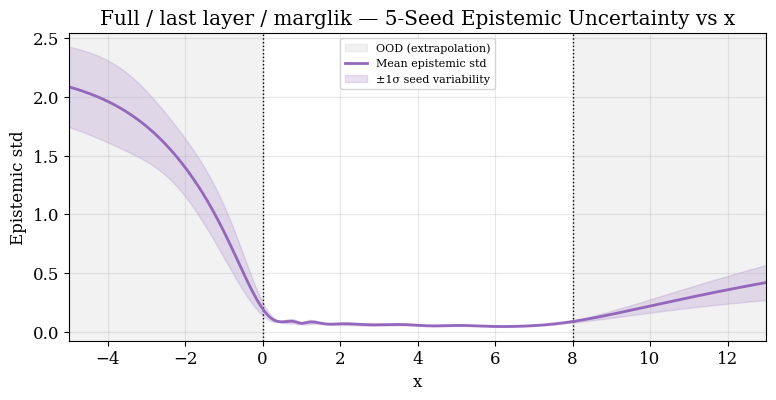

  Saved: 5seed_sinusoid_full_last_layer_marglik_ood_epistemic.png


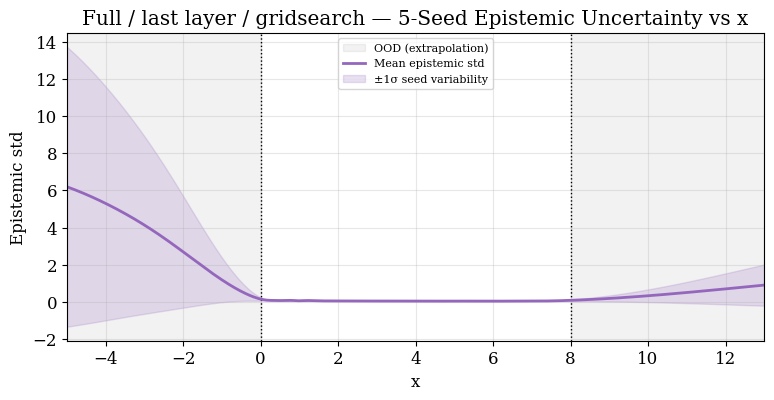

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_ood_epistemic.png


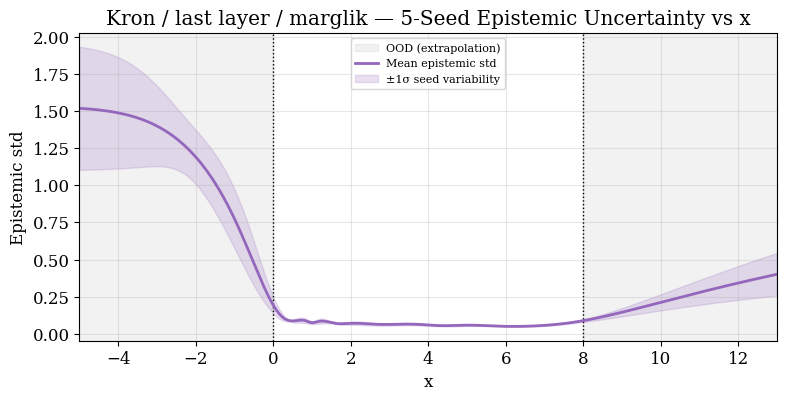

  Saved: 5seed_sinusoid_kron_last_layer_marglik_ood_epistemic.png


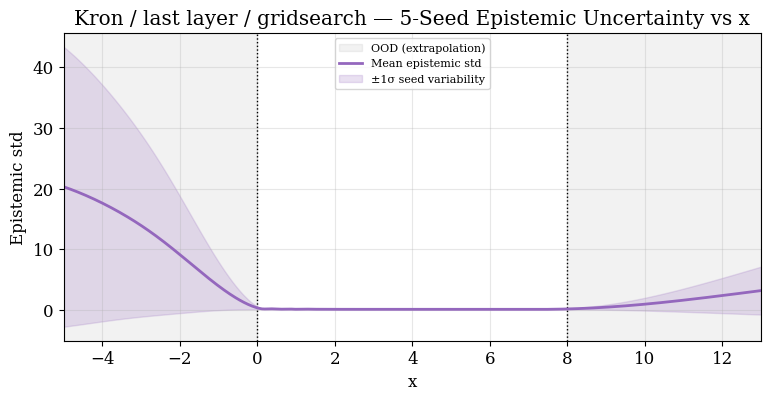

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_ood_epistemic.png


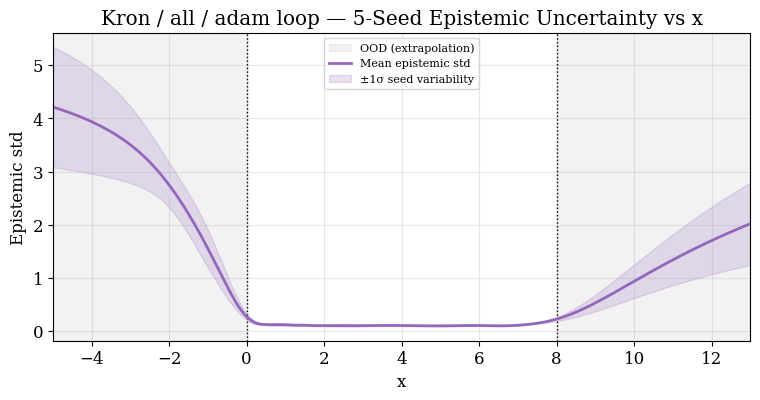

  Saved: 5seed_sinusoid_kron_all_adam_loop_ood_epistemic.png


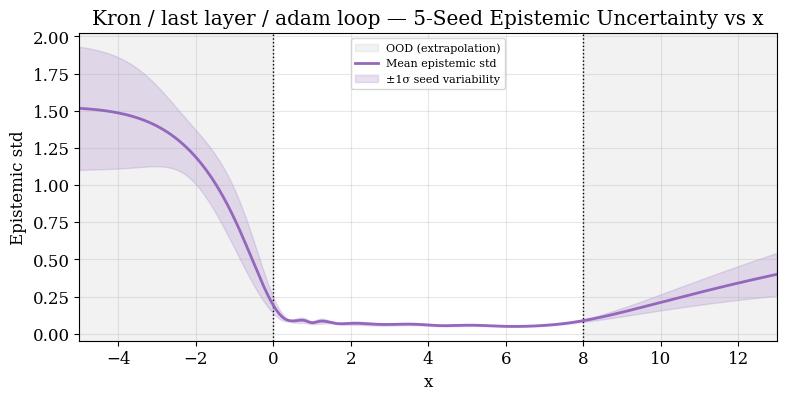

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_ood_epistemic.png

Done: 12 OOD epistemic figures


In [8]:
plot_regression_ood_epistemic(
    variant_specs, all_seed_preds, SEEDS, x_grid, TRAIN_LO, TRAIN_HI,
    FIGURES_DIR, "5seed_sinusoid")

  Seed 711: calibration done for 12 variants
  Seed 42: calibration done for 12 variants
  Seed 123: calibration done for 12 variants
  Seed 456: calibration done for 12 variants
  Seed 789: calibration done for 12 variants


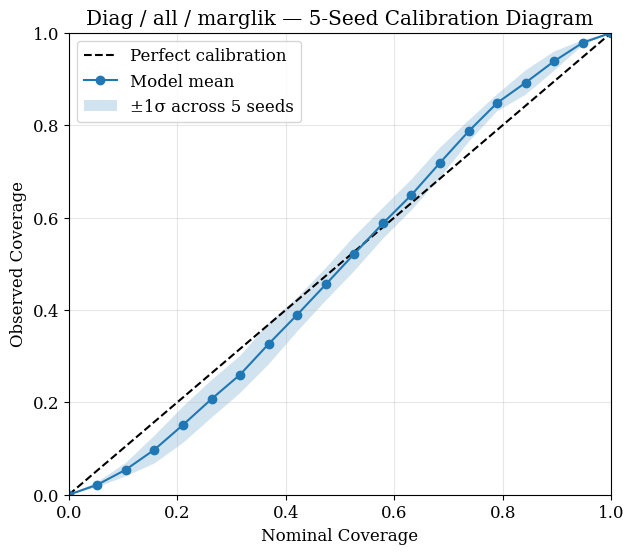

  Saved: 5seed_sinusoid_diag_all_marglik_calibration.png


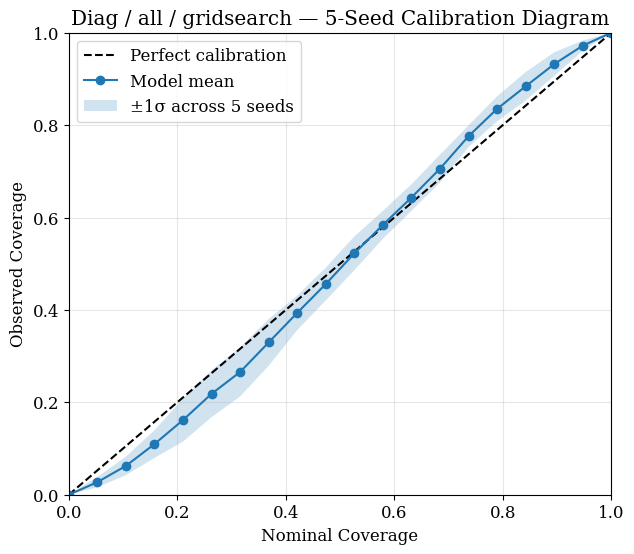

  Saved: 5seed_sinusoid_diag_all_gridsearch_calibration.png


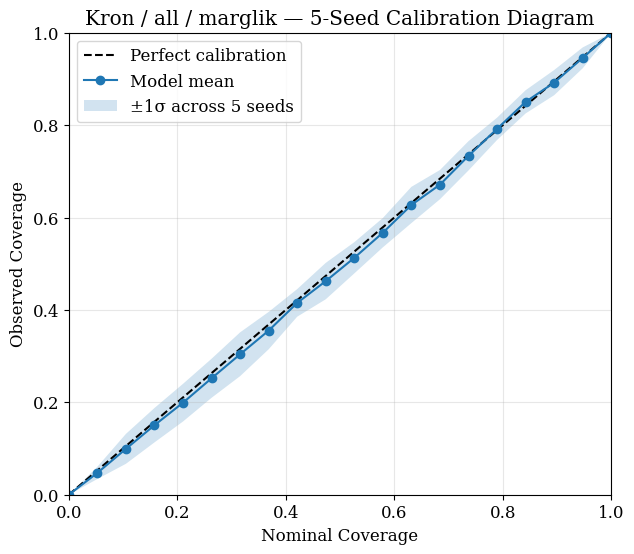

  Saved: 5seed_sinusoid_kron_all_marglik_calibration.png


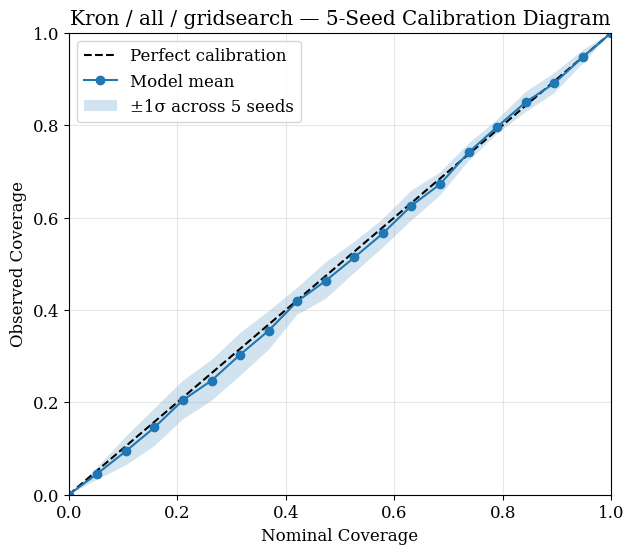

  Saved: 5seed_sinusoid_kron_all_gridsearch_calibration.png


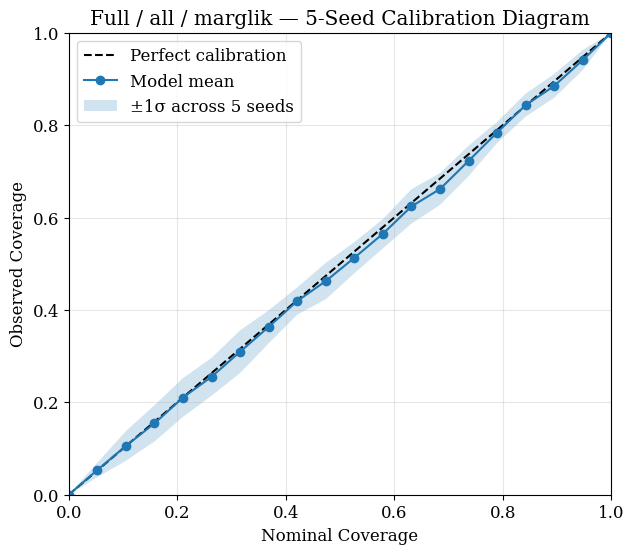

  Saved: 5seed_sinusoid_full_all_marglik_calibration.png


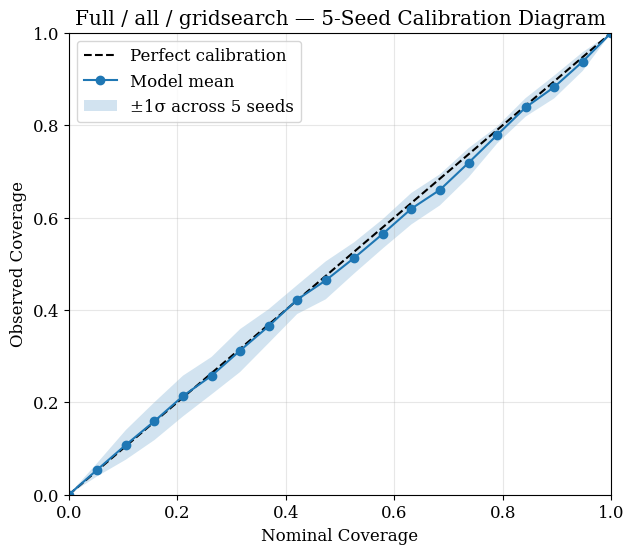

  Saved: 5seed_sinusoid_full_all_gridsearch_calibration.png


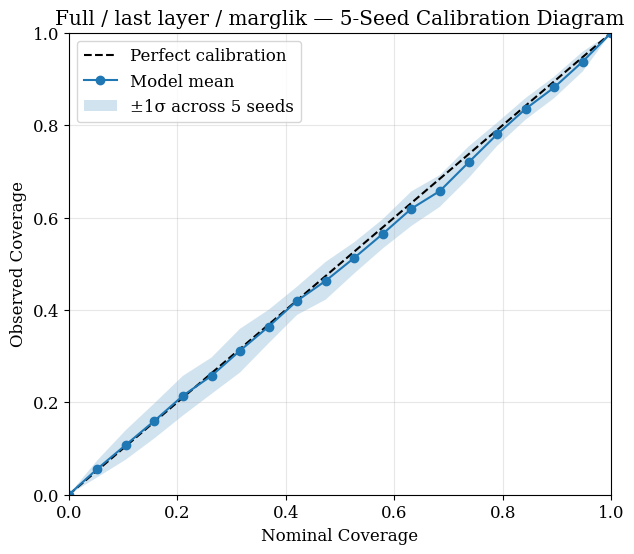

  Saved: 5seed_sinusoid_full_last_layer_marglik_calibration.png


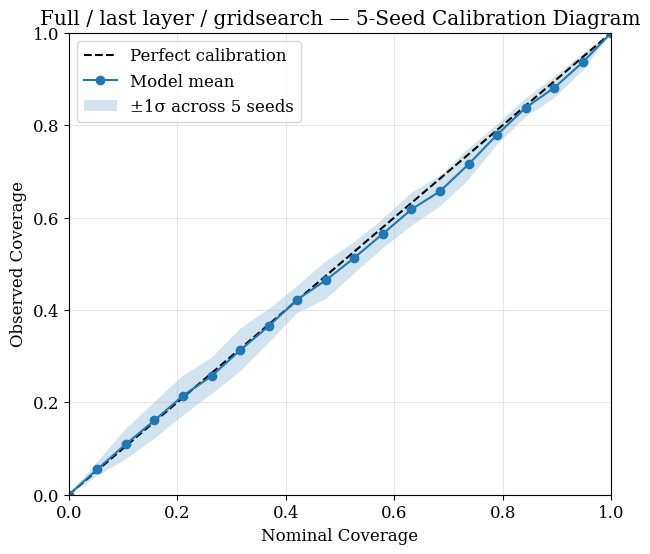

  Saved: 5seed_sinusoid_full_last_layer_gridsearch_calibration.png


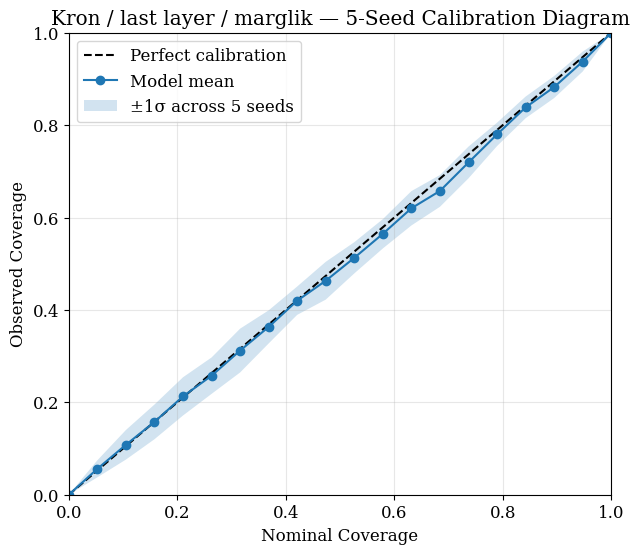

  Saved: 5seed_sinusoid_kron_last_layer_marglik_calibration.png


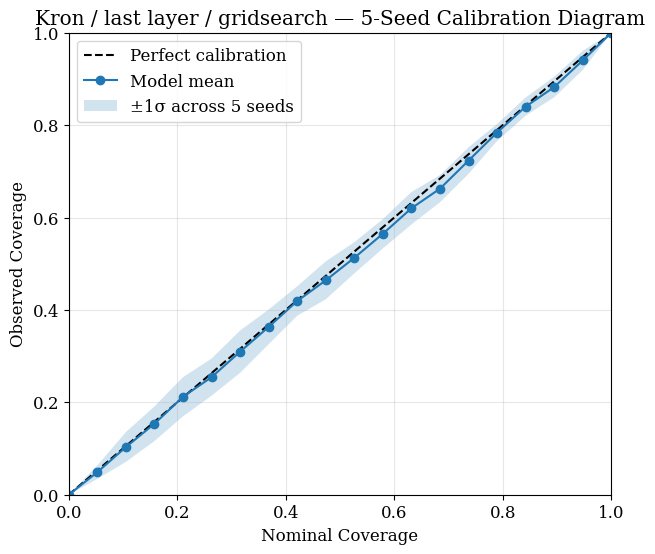

  Saved: 5seed_sinusoid_kron_last_layer_gridsearch_calibration.png


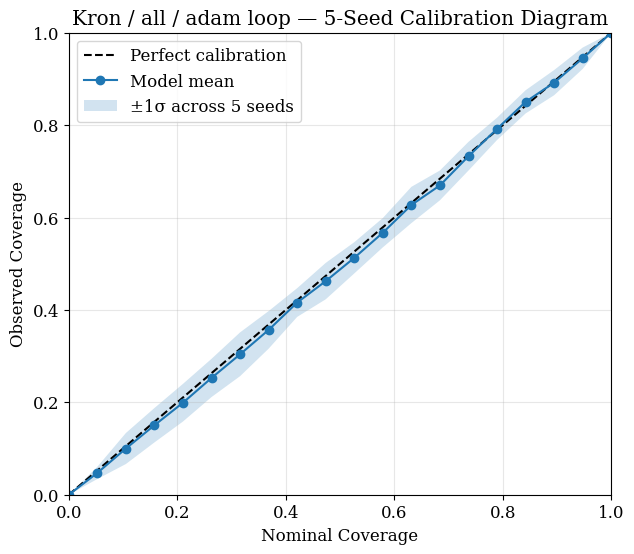

  Saved: 5seed_sinusoid_kron_all_adam_loop_calibration.png


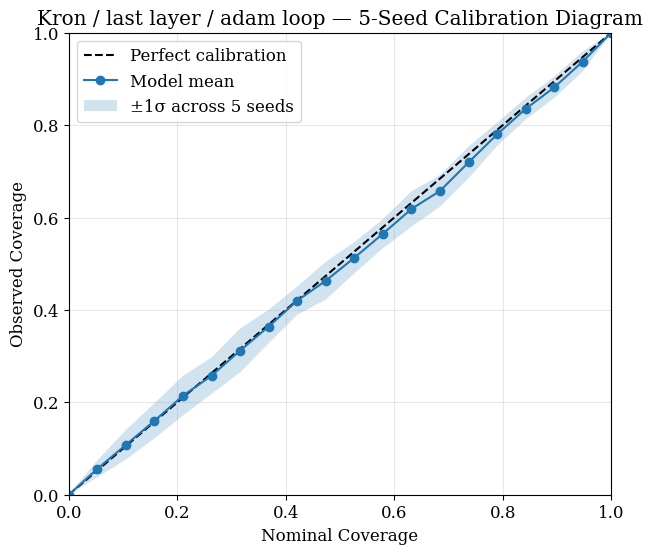

  Saved: 5seed_sinusoid_kron_last_layer_adam_loop_calibration.png

Done: 12 calibration figures


In [9]:
# Per-variant calibration curves: mean ± std across seeds
levels = np.linspace(0.0, 1.0, 20)
seed_calibration = {seed: {} for seed in SEEDS}

for seed in SEEDS:
    X_test_id_s, y_test_id_s = all_seed_test_data[seed]

    for spec in variant_specs:
        vname = spec["variant_name"]
        la = all_seed_la.get(seed, {}).get(vname)
        if la is None:
            print(f"  Warning: {vname} seed {seed} not in memory"); continue
        sigma = float(la.sigma_noise.item())
        mu_id, epi_id = la_predict(la, X_test_id_s)
        total_id = combine_predictive_std(epi_id, sigma)
        _, observed = regression_calibration_curve(y_test_id_s, mu_id, total_id, n_levels=20)
        seed_calibration[seed][vname] = observed
    print(f"  Seed {seed}: calibration done for {len(seed_calibration[seed])} variants")

plot_regression_calibration(
    variant_specs, seed_calibration, levels, SEEDS, FIGURES_DIR, "5seed_sinusoid")